## PINN Dataset Generation - Sampling Strategies

This notebook introduces and compares three sampling strategies (grid, LHS/random, and evolutionary) used for generating datasets from a synchronous machine model.

### Notebook Structure
- Imports
- Function & Helpers
- Load config and initialise models
- Grid and Random Sampling
- Introduce Evo Sampling based on LHS sampling
- Sampling Comparison

### Imports

In [7]:
# --- General Setup ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyDOE import lhs
from types import SimpleNamespace
import random

# --- ODE + Training Utilities ---
import torch
import hydra
from omegaconf import OmegaConf
from src.functions import *
from src.dataset.create_dataset_functions import ODE_modelling
from src.ode.sm_models_d import SynchronousMachineModels

# --- Plot Style ---
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["HYDRA_FULL_ERROR"] = "1"

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

print("CUDA available:", torch.cuda.is_available())

CUDA available: False


Adding seed to make notebook reproducible

In [8]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

#### Functions & Helpers

In [ ]:
def compute_ode_residual(solution, ode_func):
    """
    Compute the mean squared residual for a trajectory from solve_ivp.

    Parameters
    ----------
    solution : OdeResult
        Output from scipy.integrate.solve_ivp (has .t and .y)
    ode_func : callable
        The RHS function of the ODE, as used in solve_ivp: f(t, x)

    Returns
    -------
    float
        Mean squared residual over all time steps
    """
    t = solution.t                 # shape: [n_timesteps]
    x = solution.y.T               # shape: [n_timesteps, n_vars]
    
    # Step 1: numerical derivative dx/dt from solver output
    dxdt_numeric = np.gradient(x, t, axis=0)  # shape: [n_timesteps, n_vars]

    residuals = []

    # Step 2: evaluate residual at each time step
    for i in range(len(t)):
        t_i = t[i]
        x_i = x[i]                            # current state vector
        dxdt_model = ode_func(t_i, x_i)       # ODE RHS evaluation
        diff = dxdt_numeric[i] - dxdt_model   # difference vector
        res_sq = np.sum(diff**2)              # squared residual
        residuals.append(res_sq)

    # Step 3: return average residual across time steps
    return np.mean(residuals)

def add_noise_to_solutions(solutions, noise_std=0.01, seed=None):
    """
    Add Gaussian noise to the trajectory data of each solution.

    Parameters
    ----------
    solutions : list of OdeResult
        List of solved trajectories (from solve_ivp).
    noise_std : float
        Standard deviation of Gaussian noise (relative to signal).
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    noisy_solutions : list of OdeResult
        New list with noisy .y values (all else unchanged).
    """
    import copy

    if seed is not None:
        np.random.seed(seed)

    noisy_solutions = []

    for sol in solutions:
        noisy_sol = copy.deepcopy(sol)
        signal = sol.y
        noise = np.random.normal(loc=0.0, scale=noise_std, size=signal.shape)
        noisy_sol.y = signal + noise
        noisy_solutions.append(noisy_sol)

    return noisy_solutions

def plot_clean_vs_noisy(solution_clean, solution_noisy, var_names, var_idx=1):
    """
    Plot clean and noisy trajectory for one variable.
    """
    t = solution_clean.t
    y_clean = solution_clean.y[var_idx]
    y_noisy = solution_noisy.y[var_idx]

    plt.figure(figsize=(7, 4))
    plt.plot(t, y_clean, label="Clean", color="tab:blue")
    plt.plot(t, y_noisy, label="Noisy", color="tab:red", linestyle="--")
    plt.title(f"Clean vs. Noisy Trajectory - {var_names[var_idx]}")
    plt.xlabel("Time")
    plt.ylabel(var_names[var_idx])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_noise_difference(solution_clean, solution_noisy, var_names, var_idx=1):
    """
    Plot the difference between clean and noisy trajectory.
    """
    t = solution_clean.t
    diff = solution_noisy.y[var_idx] - solution_clean.y[var_idx]

    plt.figure(figsize=(7, 4))
    plt.plot(t, diff, color="darkorange")
    plt.title(f"Noise Difference (Noisy - Clean) - {var_names[var_idx]}")
    plt.xlabel("Time")
    plt.ylabel("Difference")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def check_high_error_focus(set4_ICs, set4_residuals, set5_ICs, top_k=200):

    set4_ICs = np.array(set4_ICs)
    set5_ICs = np.array(set5_ICs)
    set4_residuals = np.array(set4_residuals)

    # Find top-k indices
    top_k_indices = np.argsort(set4_residuals)[-top_k:]
    top_k_ICs = set4_ICs[top_k_indices]

    # Count how many top-k ICs appear in set5
    count = 0
    for ic in set5_ICs:
        if any(np.allclose(ic, top_ic) for top_ic in top_k_ICs):
            count += 1

    print(f"\n🎯 High-Error Focus Check:")
    print(f"{count}/{len(set5_ICs)} ICs in Set5 are from top-{top_k} high-residual ICs of Set4")

def plot_exploit_explore_distribution(exploit_ics, explore_ics, var_names=["theta", "omega"]):
    exploit_ics = np.array(exploit_ics)
    explore_ics = np.array(explore_ics)

    if len(var_names) < 2:
        raise ValueError("Need at least two variable names for 2D plot")

    idx_x = 0  # typically theta
    idx_y = 1  # typically omega

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(exploit_ics[:, idx_x], exploit_ics[:, idx_y], color="red", label="Exploit (High Error)", alpha=0.6)
    ax.scatter(explore_ics[:, idx_x], explore_ics[:, idx_y], color="blue", label="Explore (Random)", alpha=0.6)

    ax.set_xlabel(var_names[idx_x])
    ax.set_ylabel(var_names[idx_y])
    ax.set_title("Exploit vs. Explore ICs in Evo Sampling", pad=25)  # pad creates space below the title

    # Place legend between title and plot
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.075), ncol=2, fontsize=9)

    ax.grid(True)
    plt.tight_layout()
    plt.show()

def plot_trajectories_with_derivatives(solution_set3, solution_set4, solution_set5, var_names):
    t_vector = solution_set3[0].t  # use t from any solution
    fig, axs = plt.subplots(3, len(var_names), figsize=(4 * len(var_names), 9), sharex=True)
    
    sets = [solution_set3, solution_set4, solution_set5]
    set_labels = ["Set 3: Grid", "Set 4: Random/LHS", "Set 5: Evo"]

    for row in range(3):  # one row per set
        sol = sets[row][0]
        dy_dt = np.gradient(sol.y, t_vector, axis=1)

        for col, var in enumerate(var_names):
            
            ax = axs[row, col]
            ax.plot(t_vector, sol.y[col], color='tab:blue', label=var)
            ax.grid(True)

            # Create twin axis for derivative
            ax2 = ax.twinx()
            ax2.plot(t_vector, dy_dt[col], color='tab:red', linestyle='--', alpha=0.6, label=f"d{var}/dt")

            # Suppress right y-axis ticks unless it's the last column
            if col != len(var_names) - 1:
                ax2.tick_params(axis='y', labelleft=False, labelright=False)
            else:
                ax2.tick_params(axis='y', labelright=True, labelsize=8)

            if row == 0:
                ax.set_title(var, fontsize=10)

            if col == 0:
                ax.set_ylabel(set_labels[row], fontsize=10)

            # Optional: make left y-axis ticks smaller
            ax.tick_params(axis='y', labelsize=7)

    fig.suptitle("Trajectory and Derivative Comparison (First Sample from Each Set)", fontsize=14)
    plt.tight_layout()
    plt.show()

def quantify_trajectory_activity(time, trajectory):
    """Compute activity metrics for a 1D trajectory over time."""
    dt = np.gradient(time)
    dx_dt = np.gradient(trajectory, time)

    return {
        'std': np.std(trajectory),
        'range': np.max(trajectory) - np.min(trajectory),
        'l2_derivative': np.sqrt(np.sum(dx_dt**2 * dt)),
        'mean_abs_derivative': np.mean(np.abs(dx_dt)),
        'total_variation': np.sum(np.abs(np.diff(trajectory)))
    }

def compute_activity_for_all_solutions(solution_set, var_names):
    """Compute mean activity for each trajectory (averaged over variables)."""
    t = solution_set[0].t
    activity_summary = []

    for sol in solution_set:
        traj_metrics = []

        for var_idx in range(len(var_names)):
            traj = sol.y[var_idx]
            metrics = quantify_trajectory_activity(t, traj)
            traj_metrics.append(metrics['l2_derivative'])  # or choose any other metric

        # Average activity over variables
        mean_activity = np.mean(traj_metrics)
        activity_summary.append(mean_activity)

    return np.array(activity_summary)

def plot_ic_distributions_combined(ic_sets, var_names, titles):
    """
    Plot combined initial condition histograms for multiple sets,
    showing only non-static (variable) parameters.

    Parameters
    ----------
    ic_sets : list of list-like
        List of initial condition sets, each being a list of IC samples.
    var_names : list of str
        Names of the variables.
    titles : list of str
        Row titles for each IC set (e.g., 'Set 3', 'Set 4', ...)
    """

    # Apply seaborn styling for cleaner aesthetics
    sns.set(style="whitegrid")

    # Identify non-static (variable) columns
    all_arrays = [np.array(ic_set) for ic_set in ic_sets]
    all_data = np.concatenate(all_arrays, axis=0)
    is_variable = np.std(all_data, axis=0) > 1e-5

    variable_indices = [i for i, v in enumerate(is_variable) if v]
    variable_names = [var_names[i] for i in variable_indices]

    n_sets = len(ic_sets)
    n_vars = len(variable_indices)

    fig, axs = plt.subplots(
        n_sets, n_vars,
        figsize=(4.5 * n_vars, 2.8 * n_sets),
        constrained_layout=True
    )

    for i, ic_array in enumerate(all_arrays):
        for j, idx in enumerate(variable_indices):
            ax = axs[i, j] if n_sets > 1 else axs[j]
            data = ic_array[:, idx]

            # Smart bin selection
            unique_vals = np.unique(data)
            bins = len(unique_vals) if len(unique_vals) < 20 else 'auto'

            ax.hist(
                data,
                bins=bins,
                color=sns.color_palette("muted")[0],
                edgecolor='black',
                alpha=0.85
            )

            # Titles & labels
            if i == 0:
                ax.set_title(variable_names[j], fontsize=12)
            if j == 0:
                ax.set_ylabel(titles[i], fontsize=11)

            ax.tick_params(axis='both', labelsize=9)

    #fig.suptitle("Initial Condition Distribution", fontsize=16, y=1.02)
    plt.show()

def plot_residual_histograms_combined(residual_sets, labels, colors=None):
    """
    Plot combined residual histograms for multiple sets with mean indicators.

    Parameters
    ----------
    residual_sets : list of arrays
        Residual arrays for each dataset.
    labels : list of str
        Labels for each dataset.
    colors : list of str, optional
        Colors for each dataset.
    """
    if colors is None:
        colors = ['royalblue', 'darkorange', 'forestgreen']

    plt.figure(figsize=(8, 5))

    # Common bin edges for fair comparison
    bins = np.linspace(0, max(np.max(r) for r in residual_sets), 40)

    # Plot each histogram with transparency
    for idx, (residuals, label, color) in enumerate(zip(residual_sets, labels, colors)):
        plt.hist(residuals, bins=bins, alpha=0.5, label=label, edgecolor='black', color=color)

        # Mean line
        mean_val = np.mean(residuals)
        plt.axvline(mean_val, linestyle='--', color=color, alpha=0.8)

        # Horizontal offset for annotation to avoid overlap
        offset = 0.2 * (idx - (len(residual_sets)-1)/2.0)  # shifts left/center/right
        y_pos = plt.ylim()[1] * (0.9 - 0.05*idx)          # slight vertical stagger as well
        plt.text(mean_val + offset, y_pos, f"μ={mean_val:.2f}", 
                 color=color, fontsize=9, ha='center', va='bottom')

    plt.title("Residual Distribution Comparison", fontsize=14)
    plt.xlabel("Mean Squared Residual")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, linestyle=':', linewidth=0.7)
    plt.tight_layout()
    plt.show()

### Load config and initialise models

In [10]:
from types import SimpleNamespace

# Load configuration data -> here similar to setup_dataset.yaml, but hardcoded because of hydra issues

config = SimpleNamespace(
    wandb=SimpleNamespace(
        api_key="Add your wandb key here",
        project="Project_PINN_for_synchronous_machine"
    ),
    time=1,
    num_of_points=100,
    modelling_method=True,
    model=SimpleNamespace(
        model_flag="SM_AVR_GOV",
        machine_num=7,
        init_condition_bounds=1,
        sampling="Lhs",       
        torch=False
    ),
    dirs=SimpleNamespace(
        params_dir="src/conf/params",
        init_conditions_dir="src/conf/initial_conditions",
        dataset_dir="data"
    )
)

In [11]:
# Initialize model classes
SM_model = ODE_modelling(config)
modelling_full = SynchronousMachineModels(config)

### Grid and Random Sampling

In [12]:
# Generate initial conditions (Set 3 and Set 4)
init_conditions_set3 = SM_model.create_init_conditions_set3()
init_conditions_set4 = SM_model.create_init_conditions_set4()

# Solve the model for each IC set
solution_set3 = SM_model.solve_sm_model(init_conditions_set3, modelling_full, flag_time=True)
solution_set4 = SM_model.solve_sm_model(init_conditions_set4, modelling_full, flag_time=True)

Number of different initial conditions:  500
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m'] Variables
[[-2, 2], [-1, 1], [0], [0.9, 1.1], [1], [1.105], [1.08], [0.7048], [0.7048]] Set of values for init conditions
[10, 10, 1, 5, 1, 1, 1, 1, 1] Iterations per value
Creating 1000 initial condition samples
Variables: ['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m']
Ranges: [[-2, 2], [-1, 1], [0], [0.9, 1.1], [1], [1.105], [1.08], [0.7048], [0.7048]]
Generated 1000 initial condition samples using Lhs sampling
Mean time per iteration:  0.002673434257507324  and std:  0.00035551602926242164
Time taken to solve the model for 500 initial conditions: 1.336717128753662 seconds.
Mean time per iteration:  0.0027032508850097655  and std:  0.0015880378146712851
Time taken to solve the model for 1000 initial conditions: 2.703251838684082 seconds.


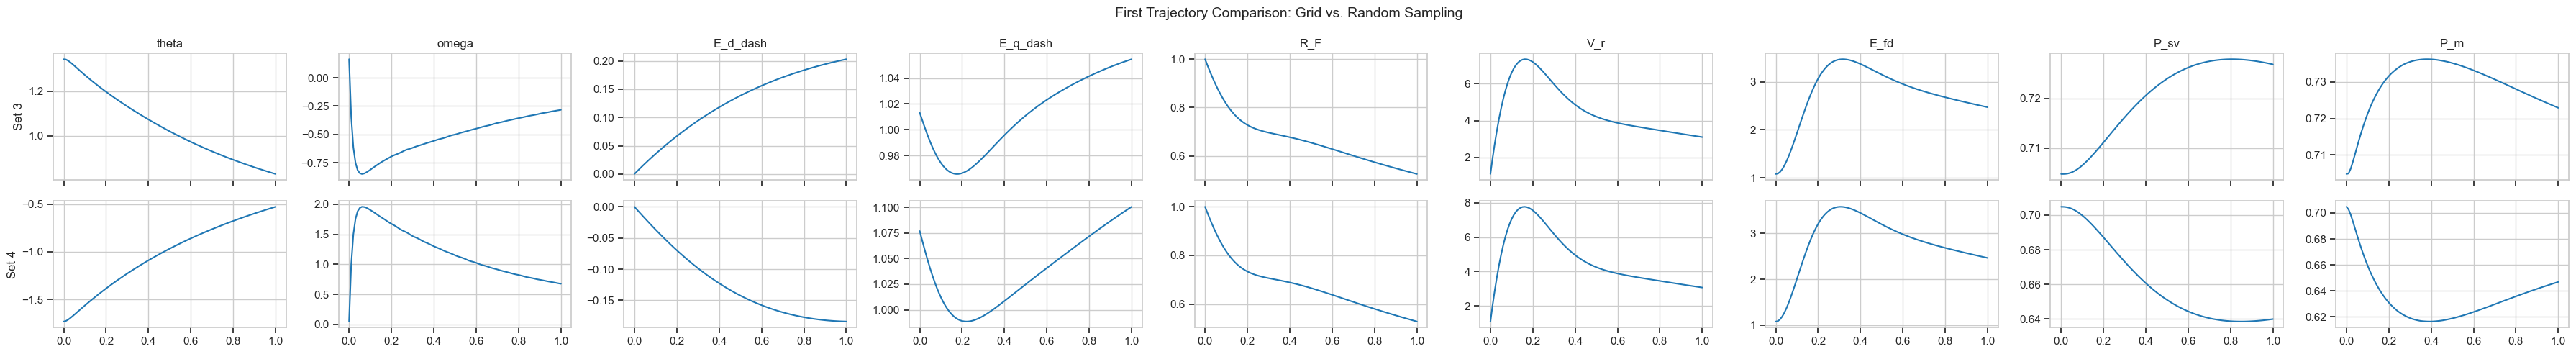

In [13]:
# plot example trajectories

var_names = ["theta", "omega", "E_d_dash", "E_q_dash", "R_F", "V_r", "E_fd", "P_sv", "P_m"]
t_vector = solution_set3[0].t

fig, axs = plt.subplots(2, len(var_names), figsize=(4 * len(var_names), 5), sharex=True)

for i, var in enumerate(var_names):
    axs[0, i].plot(t_vector, solution_set3[0].y[i])
    axs[0, i].set_title(var)
    axs[0, i].grid(True)

    axs[1, i].plot(t_vector, solution_set4[0].y[i])
    axs[1, i].grid(True)

axs[0, 0].set_ylabel("Set 3")
axs[1, 0].set_ylabel("Set 4")

fig.suptitle("First Trajectory Comparison: Grid vs. Random Sampling", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Residual computation function is already available: compute_ode_residual
residuals_set3 = [compute_ode_residual(sol, modelling_full.odequations) for sol in solution_set3]
residuals_set4 = [compute_ode_residual(sol, modelling_full.odequations) for sol in solution_set4]

print(f"Set3 - Mean Residual: {np.mean(residuals_set3):.2e}, Max: {np.max(residuals_set3):.2e}")
print(f"Set4 - Mean Residual: {np.mean(residuals_set4):.2e}, Max: {np.max(residuals_set4):.2e}")

Set3 - Mean Residual: 4.17e+00, Max: 2.57e+01
Set4 - Mean Residual: 4.40e+00, Max: 2.56e+01


### Introduce Evo Sampling based on LHS sampling

In [15]:
# Evo Sampling: Create new ICs and solve ODEs
init_conditions_set5 = SM_model.create_init_conditions_set5(
    previous_ICs=init_conditions_set4,
    previous_errors=residuals_set4,
    total_samples=1000,
    exploration_ratio=0.2  # 80% exploit, 20% explore
)
solution_set5 = SM_model.solve_sm_model(init_conditions_set5, modelling_full, flag_time=True)

[Evo Sampling] Generated 1000 ICs: 800 exploit, 200 explore
Mean time per iteration:  0.0028416731357574464  and std:  0.00043952012762773227
Time taken to solve the model for 1000 initial conditions: 2.8416740894317627 seconds.


In [16]:
# Compute residuals for Set 5 (clean)
residuals_set5 = [
    compute_ode_residual(sol, modelling_full.odequations)
    for sol in solution_set5
]

# Add noise to Set 5 and compute residuals
noisy_solution_set5 = add_noise_to_solutions(solution_set5, noise_std=0.01, seed=42)
residuals_set5_noisy = [
    compute_ode_residual(sol, modelling_full.odequations)
    for sol in noisy_solution_set5
]

# Print results
print(f"Set5 - Mean Residual: {np.mean(residuals_set5):.2e}, Max: {np.max(residuals_set5):.2e}")
print(f"Set5 Noisy - Mean Residual: {np.mean(residuals_set5_noisy):.2e}, Max: {np.max(residuals_set5_noisy):.2e}")
increase = np.mean(residuals_set5_noisy) - np.mean(residuals_set5)
print(f"→ Δ Mean Residual due to noise: {increase:.2e}")

Set5 - Mean Residual: 5.22e+00, Max: 2.58e+01
Set5 Noisy - Mean Residual: 1.24e+01, Max: 3.48e+01
→ Δ Mean Residual due to noise: 7.20e+00


In [87]:
def plot_clean_vs_noisy(solution_clean, solution_noisy, var_names, var_idx=1):
    """
    Plot clean and perturbed trajectory for one variable, with improved formatting for reporting.
    """
    t = solution_clean.t
    y_clean = solution_clean.y[var_idx]
    y_perturbed = solution_noisy.y[var_idx]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    # Plot lines
    ax.plot(t, y_clean, label="Clean", color="tab:blue", linewidth=2)
    ax.plot(t, y_perturbed, label="Noise added", color="tab:red", linestyle="--", linewidth=2, alpha=0.8)

    # Labels and title
    ax.set_xlabel("Time [s]", fontsize=12)
    ax.set_ylabel(var_names[var_idx], fontsize=12)
    #ax.set_title(f"Clean vs. Perturbed Trajectory — {var_names[var_idx]}", fontsize=13, pad=15)

    # Legend above plot
    ax.legend(loc="upper right", ncol=1, fontsize=10, frameon=False)

    # Styling
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, linestyle=":", linewidth=0.7)

    plt.tight_layout()
    plt.show()

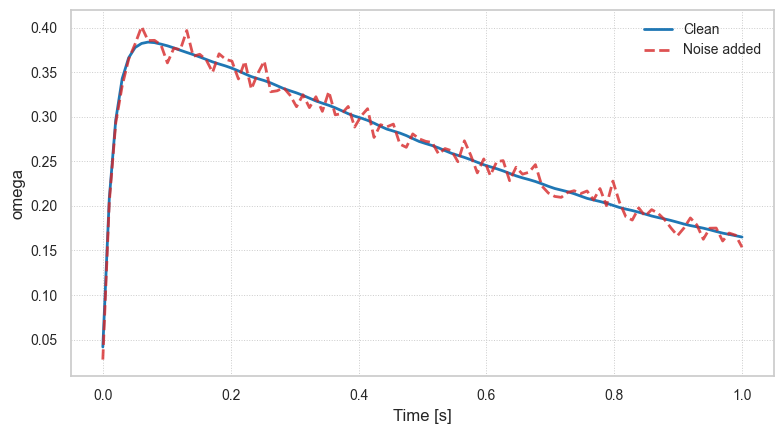

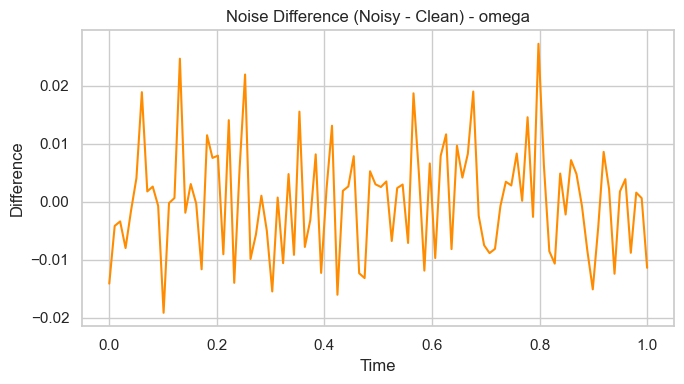

In [88]:
# Choose a sample index and variable to plot (e.g., index 1 = "omega")
sample_idx = 0
var_idx = 1  # omega

# Plot clean vs. noisy
plot_clean_vs_noisy(solution_set5[sample_idx], noisy_solution_set5[sample_idx], var_names, var_idx=var_idx)

# Plot noise difference
plot_noise_difference(solution_set5[sample_idx], noisy_solution_set5[sample_idx], var_names, var_idx=var_idx)

In [18]:
# Check if high-error ICs from Set 4 were reused in Set 5
check_high_error_focus(init_conditions_set4, residuals_set4, init_conditions_set5, top_k=800)


🎯 High-Error Focus Check:
800/1000 ICs in Set5 are from top-800 high-residual ICs of Set4


In [62]:
def plot_exploit_explore_distribution(exploit_ics, explore_ics, var_names=["theta", "omega"]):
    """
    Plot exploit vs. explore ICs in Evo sampling strategy in a clean, report-ready style.

    Parameters
    ----------
    exploit_ics : array-like
        Initial conditions selected due to high error (exploitation).
    explore_ics : array-like
        Newly sampled ICs (exploration).
    var_names : list of str
        Names of the IC variables, at least two required for 2D plot.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    exploit_ics = np.array(exploit_ics)
    explore_ics = np.array(explore_ics)

    if len(var_names) < 2:
        raise ValueError("Need at least two variable names for 2D plot")

    idx_x = 0  # e.g. theta
    idx_y = 1  # e.g. omega

    fig, ax = plt.subplots(figsize=(8, 5))  # Wider format

    ax.scatter(exploit_ics[:, idx_x], exploit_ics[:, idx_y],
               color="tab:red", label="Exploit (High Residual)", alpha=0.65, s=35)
    ax.scatter(explore_ics[:, idx_x], explore_ics[:, idx_y],
               color="tab:blue", label="Explore (LHS)", alpha=0.65, s=35)

    # Labels and title
    ax.set_xlabel(var_names[idx_x], fontsize=12)
    ax.set_ylabel(var_names[idx_y], fontsize=12)
    #ax.set_title("Evo Sampling: Exploitation vs. Exploration", fontsize=14, pad=20)

    # Legend above plot
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.085), ncol=2, fontsize=11, frameon=False)

    # Styling
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

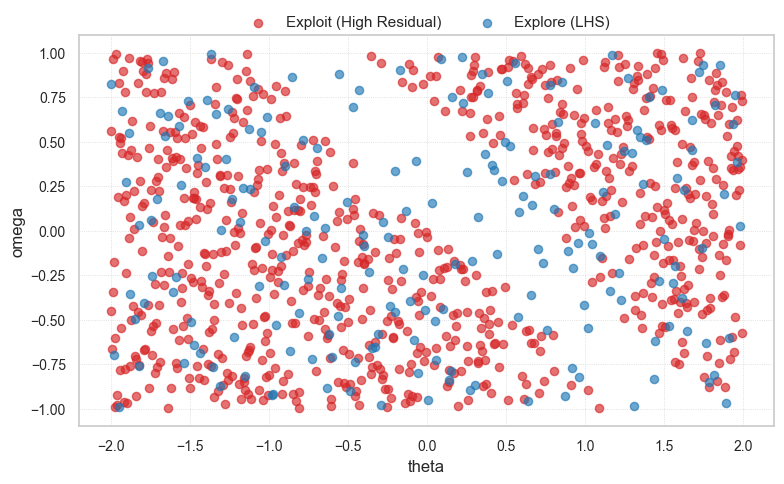

In [63]:
# Visualize exploit vs explore ICs in 2D
plot_exploit_explore_distribution(
    exploit_ics=init_conditions_set5[:800],  # First N_exploit ICs
    explore_ics=init_conditions_set5[800:],  # Remaining N_explore ICs
    var_names=["theta", "omega"]             # Adjust to suit 2D projection
)

### Comparison of Sampling Strategies

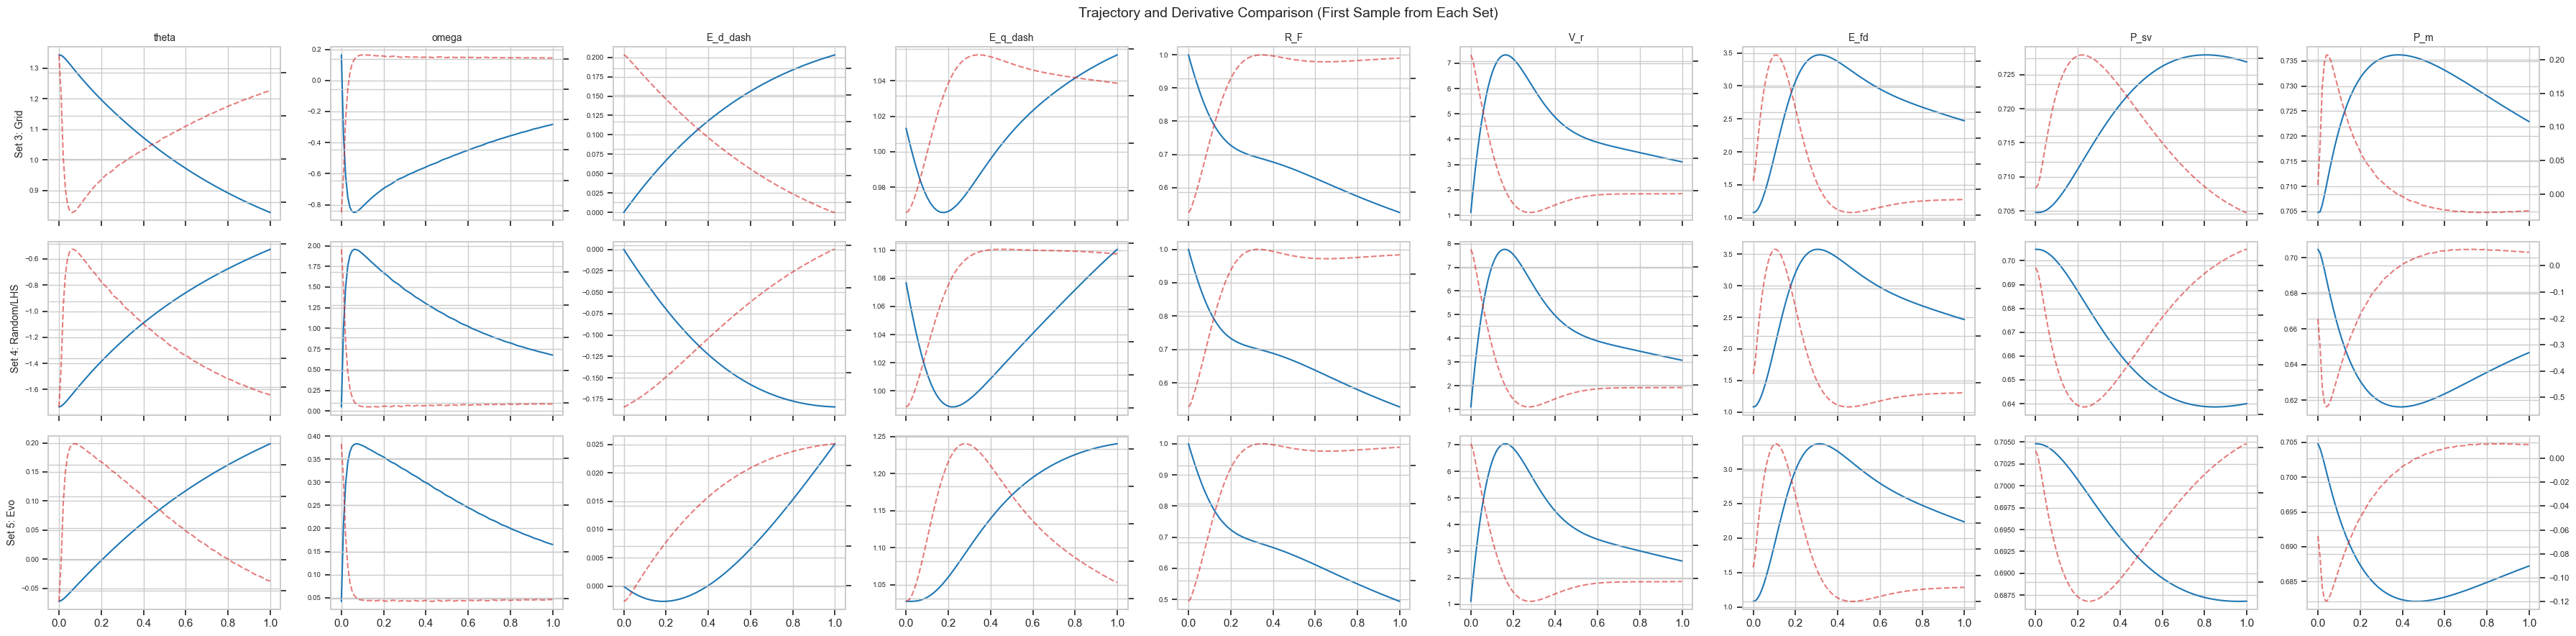

In [20]:
# Visual comparison: First trajectory from each sampling set
plot_trajectories_with_derivatives(
    solution_set3=solution_set3,
    solution_set4=solution_set4,
    solution_set5=solution_set5,
    var_names=var_names
)

#### Trajectory Activity (L2 Norm)

We quantify **trajectory activity** as the **L2 norm of the time derivative**:

$$
\text{Activity}(x) = \sqrt{\sum_{t} \left( \frac{dx}{dt}(t) \right)^2 \Delta t}
$$

This measures how strongly and how quickly the system state changes over time — higher values indicate more dynamic or complex behavior.

In [21]:
# Compute activity metrics
activity_set3 = compute_activity_for_all_solutions(solution_set3, var_names)
activity_set4 = compute_activity_for_all_solutions(solution_set4, var_names)
activity_set5 = compute_activity_for_all_solutions(solution_set5, var_names)

In [72]:
def plot_activity_distributions(activity_sets, labels, colors=None):
    """
    Plot step-style histograms for activity metrics across sampling sets.
    Mean lines are dashed and the legend shows correct color-label match with mean values.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    if colors is None:
        colors = ['royalblue', 'darkorange', 'forestgreen']

    plt.figure(figsize=(9, 5))
    bins = np.linspace(2, 6, 30)

    legend_handles = []

    for i, (activity, label, color) in enumerate(zip(activity_sets, labels, colors)):
        counts, bin_edges = np.histogram(activity, bins=bins)

        # Step histogram
        line = plt.step(bin_edges[:-1], counts, where='mid', color=color, linewidth=2)

        # Mean line
        mean_val = np.mean(activity)
        plt.axvline(mean_val, linestyle='--', color=color, linewidth=1.5)

        # Create a proxy artist with the correct label + color
        proxy = plt.Line2D([], [], color=color, linestyle='-', label=f"{label} (μ = {mean_val:.2f})")
        legend_handles.append(proxy)

    plt.xlabel("L2 Norm of Derivative (Activity)", fontsize=12)
    plt.ylabel("Number of Trajectories", fontsize=12)
    #plt.title("Activity Distribution Across Sampling Strategies", fontsize=13)
    plt.legend(handles=legend_handles, fontsize=10)
    plt.grid(True, linestyle=":", linewidth=0.6)
    plt.tight_layout()
    plt.show()

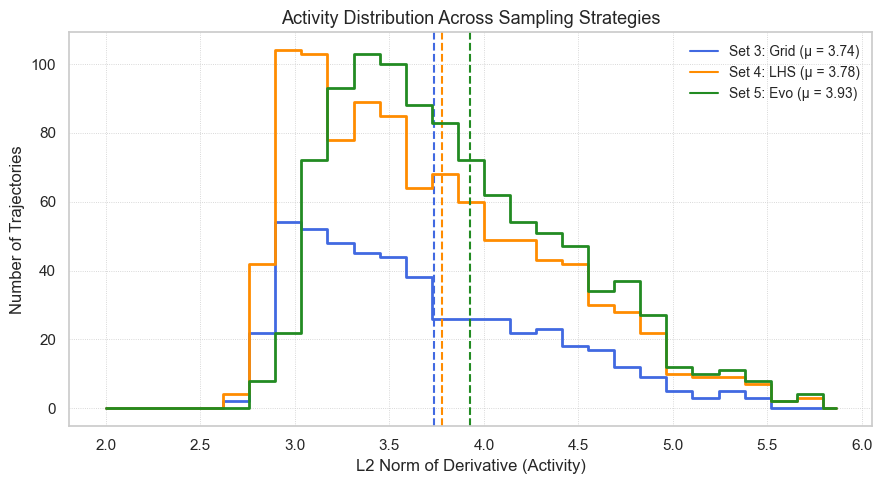

In [71]:
plot_activity_distributions(
    activity_sets=[activity_set3, activity_set4, activity_set5],
    labels=["Set 3: Grid", "Set 4: LHS", "Set 5: Evo"]
)

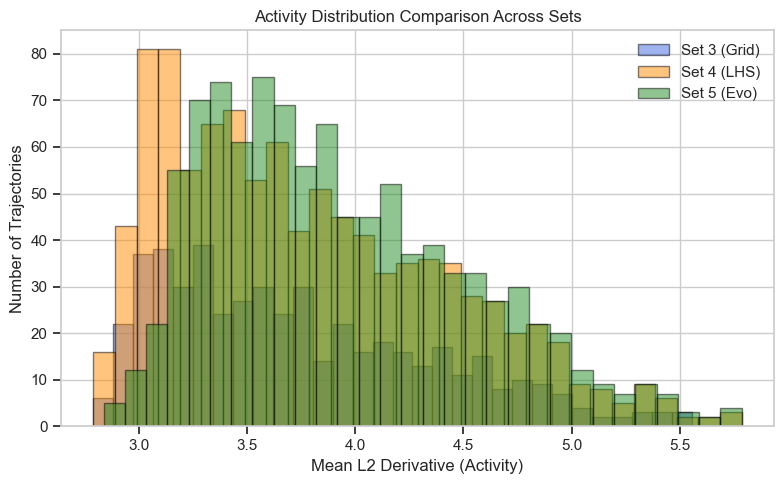

In [22]:
# Compare activity distributions
plt.figure(figsize=(8, 5))
plt.hist(activity_set3, bins=30, alpha=0.5, label='Set 3 (Grid)', color='royalblue', edgecolor='black')
plt.hist(activity_set4, bins=30, alpha=0.5, label='Set 4 (LHS)', color='darkorange', edgecolor='black')
plt.hist(activity_set5, bins=30, alpha=0.5, label='Set 5 (Evo)', color='forestgreen', edgecolor='black')

plt.xlabel("Mean L2 Derivative (Activity)")
plt.ylabel("Number of Trajectories")
plt.title("Activity Distribution Comparison Across Sets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


To understand how each sampling strategy populates the input domain, we visualize the initial condition distributions 

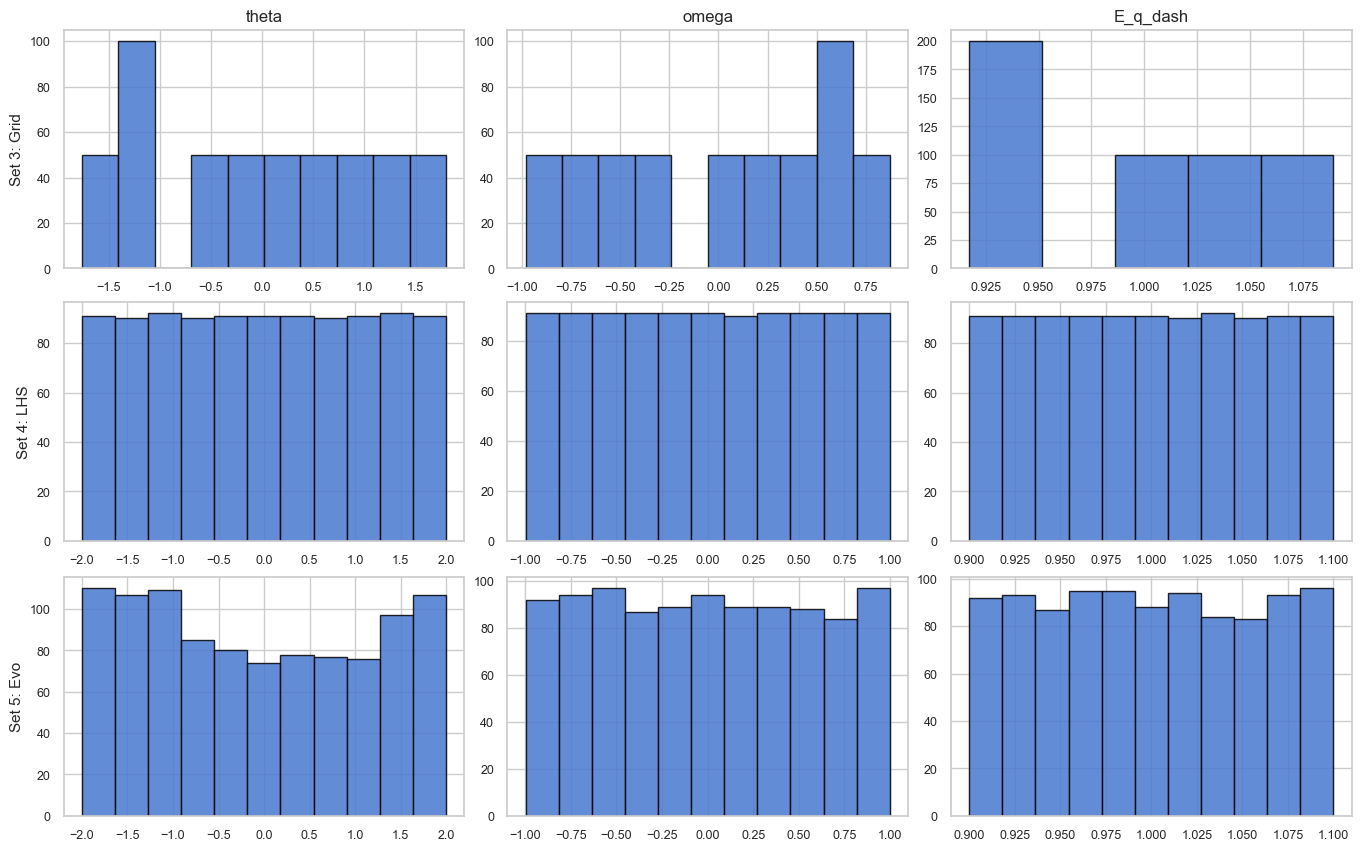

In [47]:
plot_ic_distributions_combined(
    ic_sets=[init_conditions_set3, init_conditions_set4, init_conditions_set5],
    var_names=var_names,
    titles=["Set 3: Grid", "Set 4: LHS", "Set 5: Evo"]
)

To evaluate the physical consistency of trajectories under each sampling strategy, we compute and compare the ODE residuals.


In [75]:
def plot_residual_histograms_combined(residual_sets, labels, colors=None):
    """
    Plot combined residual histograms with mean indicators and correct legend colors.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    if colors is None:
        colors = ['royalblue', 'darkorange', 'forestgreen']

    plt.figure(figsize=(9, 5))

    # Common bins across all datasets
    bins = np.linspace(0, max(np.max(r) for r in residual_sets), 40)
    legend_handles = []

    for residuals, label, color in zip(residual_sets, labels, colors):
        # Plot histogram as step line
        counts, bin_edges = np.histogram(residuals, bins=bins)
        plt.step(bin_edges[:-1], counts, where='mid', color=color, linewidth=2)

        # Mean line
        mean_val = np.mean(residuals)
        plt.axvline(mean_val, linestyle='--', color=color, linewidth=1.5)

        # Create legend handle with color + mean value
        proxy = plt.Line2D([], [], color=color, linestyle='-', 
                           label=f"{label} (μ = {mean_val:.2f})")
        legend_handles.append(proxy)

    plt.xlabel("Mean Squared Residual", fontsize=12)
    plt.ylabel("Number of Trajectories", fontsize=12)
    plt.title("Residual Distribution Across Sampling Strategies", fontsize=14)
    plt.legend(handles=legend_handles, fontsize=10)
    plt.grid(True, linestyle=':', linewidth=0.6)
    plt.tight_layout()
    plt.show()

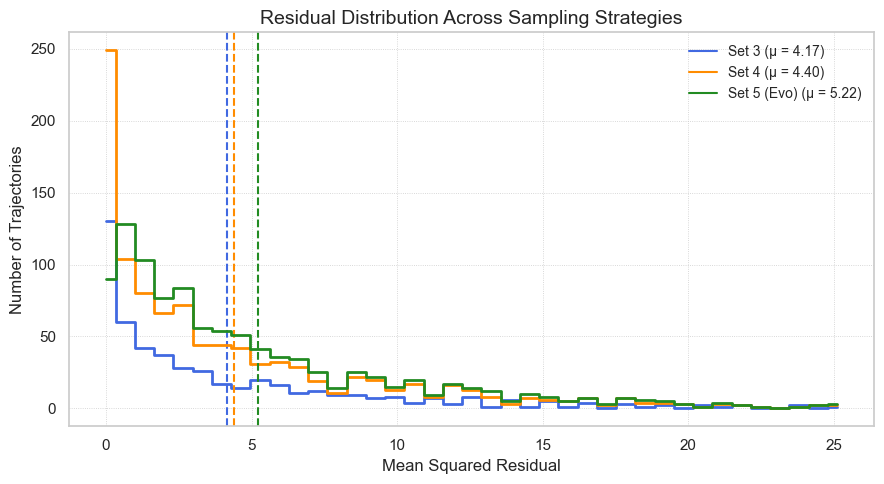

In [76]:
plot_residual_histograms_combined(
    residual_sets=[residuals_set3, residuals_set4, residuals_set5],
    labels=["Set 3", "Set 4", "Set 5 (Evo)"]
)

## Summary: Sampling Strategies for Dataset Generation in PINNs

This notebook explores and compares three different strategies for sampling initial conditions (ICs) when generating ODE-based datasets for Physics-Informed Neural Networks (PINNs):

### 1. Set 3: Grid Sampling
- Combinatorial sampling across defined value ranges.
- Very uniform, but does not scale well with many variables (curse of dimensionality).
- Produces smooth, low-residual trajectories.

### 2. Set 4: Random / LHS Sampling
- Latin Hypercube Sampling (LHS) ensures better coverage than purely random methods.
- Provides diverse ICs with better scalability.
- Captures a broader range of dynamic behavior, including higher-residual regions.

### 3. Set 5: Evo Sampling
- Adaptive strategy combining:
  - **Exploit:** Retain high-residual samples from Set 4.
  - **Explore:** Add new diverse samples using LHS.
- Focuses training data on regions where ODE is harder to learn.
- Leads to higher residuals (by design), supporting better PINN generalization.

### Additional Experiments
- Residuals computed using finite difference and model equations.
- Trajectory activity quantified using $L^2$-norm of derivatives.
- Noise robustness tested via Gaussian noise addition.

### Key Takeaways
- Evo sampling helps target regions of high model complexity.
- Residual analysis is a powerful diagnostic tool before training.
- Visual diagnostics (IC distributions, residual histograms, trajectory comparisons) reveal strengths and weaknesses of each method.

### Report Example, Synthetic Data Generation

/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_44511/3217042353.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


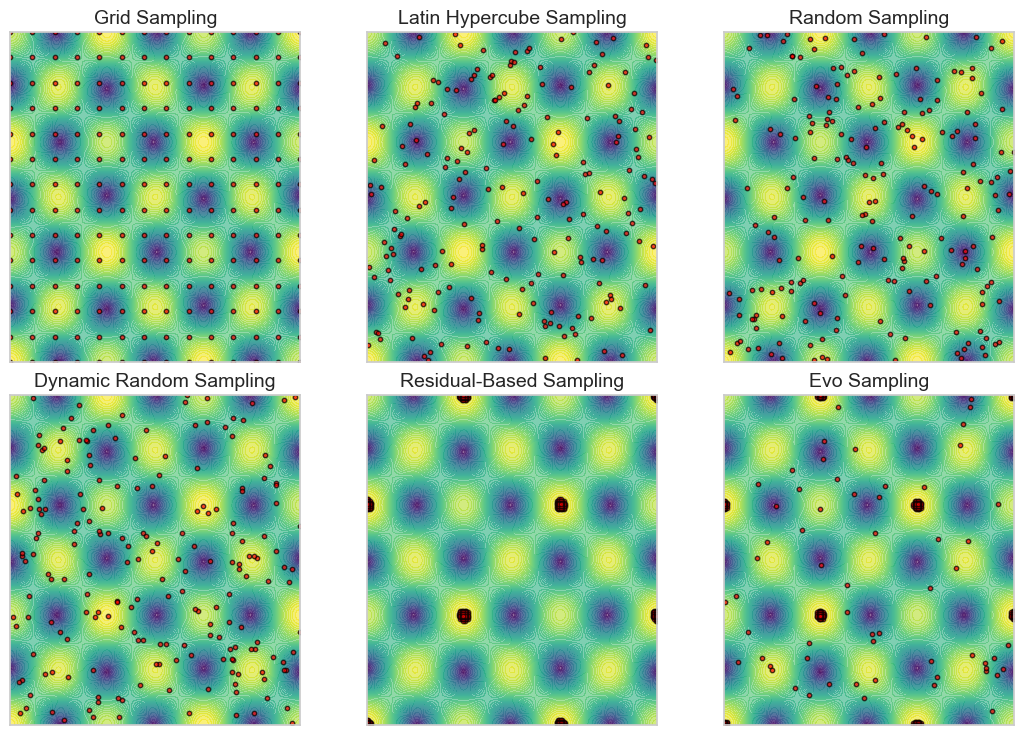

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from pyDOE import lhs
import matplotlib.gridspec as gridspec

# --- Target function and residual proxy ---
def target_function(x, y):
    return np.sin(3 * np.pi * x) * np.cos(3 * np.pi * y) + 0.5 * x

def residual_proxy(x, y):
    dx = 3 * np.pi * np.cos(3 * np.pi * x) * np.cos(3 * np.pi * y) + 0.5
    dy = -3 * np.pi * np.sin(3 * np.pi * x) * np.sin(3 * np.pi * y)
    return np.sqrt(dx**2 + dy**2)

# --- Residual heatmap grid ---
grid_x, grid_y = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
residuals = residual_proxy(grid_x, grid_y)

# --- Common sample count ---
N = 200

# --- Sampling sets ---
grid_samples = np.array([[x, y] for x in np.linspace(0, 1, int(np.sqrt(N)))
                               for y in np.linspace(0, 1, int(np.sqrt(N)))])

random_samples = np.random.rand(N, 2)

lhs_samples = lhs(2, samples=N)

flat_grid = np.column_stack([grid_x.flatten(), grid_y.flatten()])
residual_weights = residuals.flatten() / np.sum(residuals)

# Evo Sampling = top-k high-error points + random explore
top_k = int(N * 0.7)
explore_k = N - top_k
top_indices = np.argsort(residual_weights)[-top_k:]
exploit_samples = flat_grid[top_indices]
explore_samples = np.random.rand(explore_k, 2)
evo_samples = np.vstack([exploit_samples, explore_samples])

# DRS: Sample randomly with probability ∝ residuals
drs_indices = np.random.choice(len(flat_grid), size=N, replace=False, p=residual_weights)
drs_samples = flat_grid[drs_indices]

# Residual-Based Sampling (top N points by residual)
residual_based_indices = np.argsort(residual_weights)[-N:]
residual_based_samples = flat_grid[residual_based_indices]

# --- Final sampling set list ---
sampling_sets = [
    ("Grid Sampling", grid_samples),
    ("Latin Hypercube Sampling", lhs_samples),
    ("Random Sampling", random_samples),
    ("Dynamic Random Sampling", drs_samples),
    ("Residual-Based Sampling", residual_based_samples),
    ("Evo Sampling", evo_samples),

]

# --- Plotting ---
fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3, hspace=0.1)

for i, (title, samples) in enumerate(sampling_sets):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    contour = ax.contourf(grid_x, grid_y, residuals, levels=50, cmap="viridis", alpha=0.6)
    ax.scatter(samples[:, 0], samples[:, 1], s=10, c='red', alpha=0.7, edgecolor='k')
    ax.set_title(title, fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])

# Add shared colorbar
# cax = fig.add_subplot(gs[:, 3])
# cb = fig.colorbar(contour, cax=cax)
# cb.set_label("Residual Magnitude", fontsize=10)
# cb.ax.tick_params(labelsize=8)
# cb.ax.text(1.1, 0.95, 'High Error', transform=cb.ax.transAxes, fontsize=9, va='top')
# cb.ax.text(1.1, 0.05, 'Low Error', transform=cb.ax.transAxes, fontsize=9, va='bottom')

# fig.suptitle("Sampling Strategies Compared Over Residual Landscape", fontsize=16)
plt.tight_layout()
plt.show()